# 1. Business Understanding

Dieses Notebook setzt nur Random Forest ein. Das Ziel ist eine nicht-lineare Klassifikation mit Fokus auf Prognose und Interpretation, nicht auf Kausalitätsbehauptungen. Es werden zwei Richtungen untersucht: GPR -> Aktien und Aktien -> GPR.

In [1]:
from pathlib import Path
import joblib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

BASE_DIR = Path(r"d:/Anwendungsprojekt")
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
RESULTS_DIR = BASE_DIR / "results"
TABLES_DIR = RESULTS_DIR / "tables"
PLOTS_DIR = RESULTS_DIR / "plots"
MODELS_DIR = RESULTS_DIR / "models"
RF_DATASET_PATH = PROCESSED_DIR / "rf_dataset_2001_2021.csv"
INDEX_PATH = RAW_DIR / "indexData.csv"
GPR_XLS_PATH = RAW_DIR / "data_gpr_daily_recent.xls"
GPR_XLSX_PATH = RAW_DIR / "data_gpr_daily_recent.xlsx"

TRAIN_CUTOFF = pd.Period("2015-12", freq="M")
TEST_START = pd.Period("2016-01", freq="M")
FINAL_START = pd.Period("2001-01", freq="M")
FINAL_END = pd.Period("2021-05", freq="M")
RANDOM_STATE = 42
ENABLE_GRID_SEARCH = False

PARAM_GRID = {
    "n_estimators": [200, 500],
    "max_depth": [3, 4, 5],
    "min_samples_leaf": [10, 20, 50],
    "max_features": ["sqrt", "log2"],
}

FEATURES_A = [
    "GPRD_monthly_pct",
    "gpr_lag1",
    "gpr_lag2",
    "gpr_lag3",
    "GPRD_ACT_monthly_pct",
    "GPRD_THREAT_monthly_pct",
    "gprd_zscore",
    "gpr_spike",
    "Crisis_dummy",
    "Region_encoded",
]
FEATURES_B = [
    "Stock_monthly_pct",
    "stock_lag1",
    "stock_lag2",
    "stock_lag3",
    "stock_vol6",
    "gpr_spike",
    "Crisis_dummy",
    "Region_encoded",
]
TARGET_A = "target_stock_down"
TARGET_B = "target_gpr_up_lead1"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)


def clean_columns(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame.columns = frame.columns.astype(str).str.strip().str.replace(r"\s+", "_", regex=True)
    return frame


def load_gpr_file() -> pd.DataFrame:
    if GPR_XLS_PATH.exists():
        gpr_path = GPR_XLS_PATH
        engine = "xlrd"
    elif GPR_XLSX_PATH.exists():
        gpr_path = GPR_XLSX_PATH
        engine = "openpyxl"
    else:
        raise FileNotFoundError(
            f"Keine GPR-Excel-Datei gefunden. Erwartet: {GPR_XLS_PATH.name} oder {GPR_XLSX_PATH.name}."
        )

    try:
        return pd.read_excel(gpr_path, engine=engine)
    except ImportError as exc:
        raise ImportError(
            f"Die Datei {gpr_path.name} konnte nicht gelesen werden. Bitte installiere die Excel-Engine '{engine}'."
        ) from exc
    except Exception as exc:
        raise RuntimeError(f"Fehler beim Lesen von {gpr_path.name}: {exc}") from exc


def build_rf_dataset() -> pd.DataFrame:
    if not INDEX_PATH.exists():
        raise FileNotFoundError(f"Die Datei {INDEX_PATH} wurde nicht gefunden.")

    stocks = clean_columns(pd.read_csv(INDEX_PATH))
    gpr = clean_columns(load_gpr_file())

    if "Date" not in stocks.columns or "Index" not in stocks.columns:
        raise ValueError("indexData.csv muss die Spalten 'Date' und 'Index' enthalten.")

    if "date" in gpr.columns and "Date" not in gpr.columns:
        gpr = gpr.rename(columns={"date": "Date"})
    if "Date" not in gpr.columns:
        raise ValueError("Die GPR-Datei muss eine Spalte 'date' oder 'Date' enthalten.")

    required_gpr = ["GPRD", "GPRD_ACT", "GPRD_THREAT"]
    missing_gpr = [column for column in required_gpr if column not in gpr.columns]
    if missing_gpr:
        raise ValueError(f"Die GPR-Datei enthält nicht alle benötigten Spalten: {missing_gpr}")

    keep_indices = ["NYA", "IXIC", "GSPTSE", "GDAXI", "N100", "SSMI", "N225", "HSI", "000001.SS", "399001.SZ", "KS11", "TWII"]
    exclude_indices = ["NSEI", "J203.JO"]

    stocks["Date"] = pd.to_datetime(stocks["Date"], errors="coerce")
    stocks["Index"] = stocks["Index"].astype(str).str.strip()
    stocks = stocks.dropna(subset=["Date", "Close"])
    stocks = stocks[~stocks["Index"].isin(exclude_indices)].copy()
    stocks = stocks[stocks["Index"].isin(keep_indices)].copy()
    stocks = stocks.sort_values(["Index", "Date"]).reset_index(drop=True)

    gpr["Date"] = pd.to_datetime(gpr["Date"], errors="coerce")
    gpr = gpr.dropna(subset=["Date"]).copy()
    gpr = gpr.sort_values("Date").reset_index(drop=True)

    stocks_monthly = (
        stocks.assign(YearMonth=stocks["Date"].dt.to_period("M"))
        .sort_values(["Index", "Date"])
        .groupby(["Index", "YearMonth"], as_index=False)
        .tail(1)
        .copy()
    )
    stocks_monthly["Stock_monthly_pct"] = stocks_monthly.groupby("Index")["Close"].pct_change() * 100
    stocks_monthly["stock_lag1"] = stocks_monthly.groupby("Index")["Stock_monthly_pct"].shift(1)
    stocks_monthly["stock_lag2"] = stocks_monthly.groupby("Index")["Stock_monthly_pct"].shift(2)
    stocks_monthly["stock_lag3"] = stocks_monthly.groupby("Index")["Stock_monthly_pct"].shift(3)
    stocks_monthly["stock_vol6"] = stocks_monthly.groupby("Index")["Stock_monthly_pct"].transform(
        lambda series: series.rolling(window=6, min_periods=6).std()
    )
    stocks_monthly = stocks_monthly.rename(columns={"Close": "Close_month_end"})

    monthly_gpr = (
        gpr.assign(YearMonth=gpr["Date"].dt.to_period("M"))
        .groupby("YearMonth", as_index=False)[required_gpr]
        .mean()
        .sort_values("YearMonth")
        .reset_index(drop=True)
    )
    monthly_gpr["GPRD_monthly_pct"] = monthly_gpr["GPRD"].pct_change() * 100
    monthly_gpr["GPRD_ACT_monthly_pct"] = monthly_gpr["GPRD_ACT"].pct_change() * 100
    monthly_gpr["GPRD_THREAT_monthly_pct"] = monthly_gpr["GPRD_THREAT"].pct_change() * 100
    monthly_gpr["gpr_lag1"] = monthly_gpr["GPRD_monthly_pct"].shift(1)
    monthly_gpr["gpr_lag2"] = monthly_gpr["GPRD_monthly_pct"].shift(2)
    monthly_gpr["gpr_lag3"] = monthly_gpr["GPRD_monthly_pct"].shift(3)
    monthly_gpr["GPRD_monthly_pct_lead1"] = monthly_gpr["GPRD_monthly_pct"].shift(-1)
    monthly_gpr["gprd_zscore"] = (
        monthly_gpr["GPRD"] - monthly_gpr["GPRD"].rolling(window=24, min_periods=24).mean()
    ) / monthly_gpr["GPRD"].rolling(window=24, min_periods=24).std()

    train_monthly = monthly_gpr[monthly_gpr["YearMonth"] <= TRAIN_CUTOFF]
    train_returns = train_monthly["GPRD_monthly_pct"].dropna()
    if train_returns.empty:
        raise ValueError("Für den Trainingszeitraum bis 2015-12 konnte keine GPR-Rendite für die Spike-Schwelle berechnet werden.")
    gpr_spike_threshold = train_returns.mean() + train_returns.std()
    monthly_gpr["gpr_spike"] = (monthly_gpr["GPRD_monthly_pct"] > gpr_spike_threshold).astype(int)

    crisis_periods = [
        ("2001-08", "2002-06"),
        ("2008-08", "2009-06"),
        ("2011-01", "2011-09"),
        ("2014-02", "2014-09"),
        ("2020-01", "2020-06"),
    ]
    region_map = {
        "NYA": "USA",
        "IXIC": "USA",
        "GSPTSE": "Nordamerika",
        "GDAXI": "Europa",
        "N100": "Europa",
        "SSMI": "Europa",
        "N225": "Japan",
        "HSI": "China_HK",
        "000001.SS": "China_HK",
        "399001.SZ": "China_HK",
        "KS11": "Asien_Pazifik",
        "TWII": "Asien_Pazifik",
    }

    panel = stocks_monthly.merge(monthly_gpr, on="YearMonth", how="left")
    panel["YearMonth"] = panel["YearMonth"].astype(str)
    panel["Region"] = panel["Index"].map(region_map)
    if panel["Region"].isna().any():
        missing_indices = sorted(panel.loc[panel["Region"].isna(), "Index"].unique())
        raise ValueError(f"Für folgende Indizes fehlt eine Regionszuordnung: {missing_indices}")

    region_encoder = LabelEncoder()
    panel["Region_encoded"] = region_encoder.fit_transform(panel["Region"])
    panel["Crisis_dummy"] = 0
    for crisis_start, crisis_end in crisis_periods:
        crisis_mask = (pd.PeriodIndex(panel["YearMonth"], freq="M") >= pd.Period(crisis_start, freq="M")) & (pd.PeriodIndex(panel["YearMonth"], freq="M") <= pd.Period(crisis_end, freq="M"))
        panel.loc[crisis_mask, "Crisis_dummy"] = 1

    panel["target_stock_down"] = (panel["Stock_monthly_pct"] < 0).astype(int)
    panel["target_gpr_up_lead1"] = (panel["GPRD_monthly_pct_lead1"] > 0).astype(int)

    final_start = pd.Period("2001-01", freq="M")
    final_end = pd.Period("2021-05", freq="M")
    panel = panel[(pd.PeriodIndex(panel["YearMonth"], freq="M") >= final_start) & (pd.PeriodIndex(panel["YearMonth"], freq="M") <= final_end)].copy()

    final_columns = [
        "YearMonth",
        "Index",
        "Region",
        "Region_encoded",
        "Close_month_end",
        "Stock_monthly_pct",
        "stock_lag1",
        "stock_lag2",
        "stock_lag3",
        "stock_vol6",
        "GPRD",
        "GPRD_ACT",
        "GPRD_THREAT",
        "GPRD_monthly_pct",
        "GPRD_ACT_monthly_pct",
        "GPRD_THREAT_monthly_pct",
        "GPRD_monthly_pct_lead1",
        "gpr_lag1",
        "gpr_lag2",
        "gpr_lag3",
        "gprd_zscore",
        "gpr_spike",
        "Crisis_dummy",
        "target_stock_down",
        "target_gpr_up_lead1",
    ]
    panel = panel[final_columns].dropna().reset_index(drop=True)
    RF_DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)
    panel.to_csv(RF_DATASET_PATH, index=False)
    return panel


if not RF_DATASET_PATH.exists():
    build_rf_dataset()

print(f"Arbeitsverzeichnis: {BASE_DIR}")
print(f"Random-Forest-Datensatz: {RF_DATASET_PATH}")
print(f"GridSearch aktiviert: {ENABLE_GRID_SEARCH}")

Arbeitsverzeichnis: d:\Anwendungsprojekt
Random-Forest-Datensatz: d:\Anwendungsprojekt\data\processed\rf_dataset_2001_2021.csv
GridSearch aktiviert: False


# 2. Data Understanding

Hier laden wir den finalen Random-Forest-Datensatz und prüfen Abdeckung, Zeitraum, Vollständigkeit und Zielverteilungen.

In [2]:
rf_data = pd.read_csv(RF_DATASET_PATH)
rf_data["YearMonth"] = pd.PeriodIndex(rf_data["YearMonth"], freq="M")
rf_data = rf_data.sort_values(["YearMonth", "Index"]).reset_index(drop=True)

print(f"Shape: {rf_data.shape}")
display(rf_data.head())
print("\nInfo:")
rf_data.info()
print(f"\nStart month: {rf_data['YearMonth'].min()}")
print(f"End month: {rf_data['YearMonth'].max()}")
print(f"Number of months: {rf_data['YearMonth'].nunique()}")
print(f"Number of indices: {rf_data['Index'].nunique()}")
print("\nObservations per index:")
display(rf_data["Index"].value_counts().sort_index())
print("\nMissing values:")
display(rf_data.isna().sum())
print("\nClass distribution target_stock_down:")
display(rf_data["target_stock_down"].value_counts().sort_index())
print("\nClass distribution target_gpr_up_lead1:")
display(rf_data["target_gpr_up_lead1"].value_counts().sort_index())

Shape: (2940, 25)


,YearMonth,Index,Region,Region_encoded,Close_month_end,Stock_monthly_pct,stock_lag1,stock_lag2,stock_lag3,stock_vol6,GPRD,GPRD_ACT,GPRD_THREAT,GPRD_monthly_pct,GPRD_ACT_monthly_pct,GPRD_THREAT_monthly_pct,GPRD_monthly_pct_lead1,gpr_lag1,gpr_lag2,gpr_lag3,gprd_zscore,gpr_spike,Crisis_dummy,target_stock_down,target_gpr_up_lead1
0,2001-01,000001.SS,China_HK,1,2065.605957,-0.379608,0.138317,5.574200,2.676527,3.677836,47.345442,39.250704,53.581266,2.898991,-11.863157,14.962543,18.989928,1.256795,-39.288447,41.867346,-1.127671,0.0,0,1,1
1,2001-01,399001.SZ,China_HK,1,4743.370117,-0.197357,-1.627075,5.644593,1.095574,3.891984,47.345442,39.250704,53.581266,2.898991,-11.863157,14.962543,18.989928,1.256795,-39.288447,41.867346,-1.127671,0.0,0,1,1
2,2001-01,GDAXI,Europa,2,6795.140137,5.619400,0.961654,-9.962781,4.108780,5.978030,47.345442,39.250704,53.581266,2.898991,-11.863157,14.962543,18.989928,1.256795,-39.288447,41.867346,-1.127671,0.0,0,0,1
3,2001-01,GSPTSE,Nordamerika,4,9321.900391,4.345346,1.290262,-8.503457,-7.114163,7.116822,47.345442,39.250704,53.581266,2.898991,-11.863157,14.962543,18.989928,1.256795,-39.288447,41.867346,-1.127671,0.0,0,0,1
4,2001-01,HSI,China_HK,1,16102.349610,6.669652,7.945578,-6.115672,-4.815909,6.935874,47.345442,39.250704,53.581266,2.898991,-11.863157,14.962543,18.989928,1.256795,-39.288447,41.867346,-1.127671,0.0,0,0,1



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype    
---  ------                   --------------  -----    
 0   YearMonth                2940 non-null   period[M]
 1   Index                    2940 non-null   object   
 2   Region                   2940 non-null   object   
 3   Region_encoded           2940 non-null   int64    
 4   Close_month_end          2940 non-null   float64  
 5   Stock_monthly_pct        2940 non-null   float64  
 6   stock_lag1               2940 non-null   float64  
 7   stock_lag2               2940 non-null   float64  
 8   stock_lag3               2940 non-null   float64  
 9   stock_vol6               2940 non-null   float64  
 10  GPRD                     2940 non-null   float64  
 11  GPRD_ACT                 2940 non-null   float64  
 12  GPRD_THREAT              2940 non-null   float64  
 13  GPRD_monthly_pct         2940 non-null   

Index
000001.SS    245
399001.SZ    245
GDAXI        245
GSPTSE       245
HSI          245
IXIC         245
KS11         245
N100         245
N225         245
NYA          245
SSMI         245
TWII         245
Name: count, dtype: int64


Missing values:


YearMonth                  0
Index                      0
Region                     0
Region_encoded             0
Close_month_end            0
Stock_monthly_pct          0
stock_lag1                 0
stock_lag2                 0
stock_lag3                 0
stock_vol6                 0
GPRD                       0
GPRD_ACT                   0
GPRD_THREAT                0
GPRD_monthly_pct           0
GPRD_ACT_monthly_pct       0
GPRD_THREAT_monthly_pct    0
GPRD_monthly_pct_lead1     0
gpr_lag1                   0
gpr_lag2                   0
gpr_lag3                   0
gprd_zscore                0
gpr_spike                  0
Crisis_dummy               0
target_stock_down          0
target_gpr_up_lead1        0
dtype: int64


Class distribution target_stock_down:


target_stock_down
0    1707
1    1233
Name: count, dtype: int64


Class distribution target_gpr_up_lead1:


target_gpr_up_lead1
0    1512
1    1428
Name: count, dtype: int64

# 3. Data Preparation

Wir erstellen den chronologischen Split und definieren die Feature-Sets für beide Richtungen. Identifikationsspalten, Zielvariablen und Lead-Spalten werden konsequent aus den Features ausgeschlossen.

In [3]:
rf_data["YearMonth"] = pd.PeriodIndex(rf_data["YearMonth"], freq="M")
rf_data = rf_data.sort_values(["YearMonth", "Index"]).reset_index(drop=True)
train_mask = rf_data["YearMonth"] <= TRAIN_CUTOFF
test_mask = rf_data["YearMonth"] >= TEST_START

identifier_cols = ["YearMonth", "Index", "Region"]
blocked_cols = {
    "target_stock_down",
    "target_gpr_up_lead1",
    "GPRD_monthly_pct_lead1",
    "gprd_ret_lead1",
    "gprd_ret_lead2",
    "gprd_ret_lead3",
}

train_df = rf_data.loc[train_mask].copy().sort_values(["YearMonth", "Index"]).reset_index(drop=True)
test_df = rf_data.loc[test_mask].copy().sort_values(["YearMonth", "Index"]).reset_index(drop=True)

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Train months: {train_df['YearMonth'].min()} to {train_df['YearMonth'].max()}")
print(f"Test months: {test_df['YearMonth'].min()} to {test_df['YearMonth'].max()}")


def make_xy(frame: pd.DataFrame, feature_columns: list[str], target_column: str):
    usable_columns = [column for column in feature_columns if column not in blocked_cols and column not in identifier_cols]
    X = frame[usable_columns].copy()
    y = frame[target_column].copy()
    return X, y, usable_columns


def save_feature_importance(model: RandomForestClassifier, feature_names: list[str], direction_label: str):
    importance_frame = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_,
    }).sort_values("Importance", ascending=False).reset_index(drop=True)

    table_path = TABLES_DIR / f"rf_feature_importance_{direction_label}.csv"
    plot_path = PLOTS_DIR / f"rf_feature_importance_{direction_label}.png"
    importance_frame.to_csv(table_path, index=False)

    top_15 = importance_frame.head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_15["Feature"][::-1], top_15["Importance"][::-1], color="#264653")
    ax.set_title(f"Random Forest Feature Importance - {direction_label}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    fig.tight_layout()
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()
    return importance_frame


def save_classification_plots(y_true, y_pred, y_proba, direction_label: str):
    cm_path = PLOTS_DIR / f"rf_confusion_matrix_{direction_label}.png"
    roc_path = PLOTS_DIR / f"rf_roc_curve_{direction_label}.png"

    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap="Blues", ax=ax_cm, colorbar=False)
    ax_cm.set_title(f"Confusion Matrix - {direction_label}")
    fig_cm.tight_layout()
    fig_cm.savefig(cm_path, dpi=200, bbox_inches="tight")
    plt.show()

    fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_true, y_proba, ax=ax_roc)
    ax_roc.set_title(f"ROC Curve - {direction_label}")
    fig_roc.tight_layout()
    fig_roc.savefig(roc_path, dpi=200, bbox_inches="tight")
    plt.show()



def fit_and_evaluate_direction(direction_label: str, feature_columns: list[str], target_column: str):
    X_train, y_train, selected_features = make_xy(train_df, feature_columns, target_column)
    X_test, y_test, _ = make_xy(test_df, feature_columns, target_column)

    base_model = RandomForestClassifier(
        n_estimators=500,
        max_depth=5,
        min_samples_leaf=20,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    best_params = None
    cv_best_score = None
    if ENABLE_GRID_SEARCH:
        cv = TimeSeriesSplit(n_splits=5, gap=1)
        search = GridSearchCV(
            estimator=base_model,
            param_grid=PARAM_GRID,
            scoring="roc_auc",
            cv=cv,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_train, y_train)
        model = search.best_estimator_
        best_params = search.best_params_
        cv_best_score = search.best_score_
    else:
        model = base_model.fit(X_train, y_train)
        best_params = model.get_params()

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Direction": direction_label,
        "Target": target_column,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "Baseline_Accuracy": max(y_test.mean(), 1 - y_test.mean()),
    }

    print(f"\n{direction_label} - Classification report")
    print(classification_report(y_test, y_pred, zero_division=0))
    print(f"{direction_label} - Confusion matrix")
    print(confusion_matrix(y_test, y_pred))
    if cv_best_score is not None:
        print(f"{direction_label} - Best CV ROC-AUC: {cv_best_score:.4f}")
        print(f"{direction_label} - Best params: {best_params}")

    save_classification_plots(y_test, y_pred, y_proba, direction_label)
    importance_frame = save_feature_importance(model, selected_features, direction_label)

    model_path = MODELS_DIR / f"random_forest_{direction_label}.pkl"
    joblib.dump(model, model_path)

    return {
        "model": model,
        "metrics": metrics,
        "importance": importance_frame,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "selected_features": selected_features,
        "best_params": best_params,
        "cv_best_score": cv_best_score,
        "model_path": model_path,
    }


for directory in [RESULTS_DIR, TABLES_DIR, PLOTS_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Feature sets ready.")
print(f"Direction A features: {FEATURES_A}")
print(f"Direction B features: {FEATURES_B}")

Train shape: (2160, 25)
Test shape: (780, 25)
Train months: 2001-01 to 2015-12
Test months: 2016-01 to 2021-05
Feature sets ready.
Direction A features: ['GPRD_monthly_pct', 'gpr_lag1', 'gpr_lag2', 'gpr_lag3', 'GPRD_ACT_monthly_pct', 'GPRD_THREAT_monthly_pct', 'gprd_zscore', 'gpr_spike', 'Crisis_dummy', 'Region_encoded']
Direction B features: ['Stock_monthly_pct', 'stock_lag1', 'stock_lag2', 'stock_lag3', 'stock_vol6', 'gpr_spike', 'Crisis_dummy', 'Region_encoded']


# 6. Hyperparameter Tuning

Optionales GridSearchCV ist in der Trainingsfunktion eingebaut und läuft nur auf dem Trainingszeitraum. Aktiviere `ENABLE_GRID_SEARCH = True`, wenn du die Parametersuche ausführen möchtest.

# 4. Modeling - Random Forest Richtung A

Richtung A modelliert den Zusammenhang GPR -> Aktien mit `target_stock_down` als Zielvariable.


direction_A - Classification report
              precision    recall  f1-score   support

           0       0.62      0.54      0.58       492
           1       0.35      0.42      0.38       288

    accuracy                           0.50       780
   macro avg       0.48      0.48      0.48       780
weighted avg       0.52      0.50      0.51       780

direction_A - Confusion matrix
[[267 225]
 [166 122]]


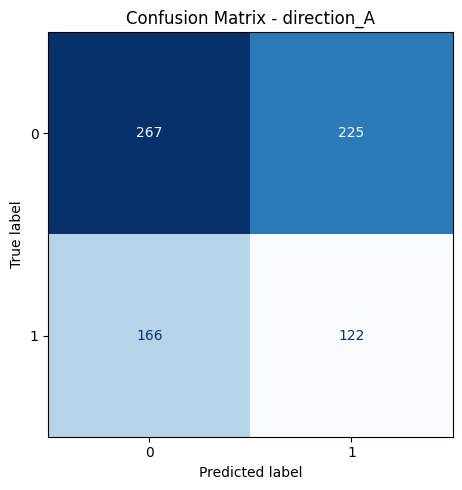

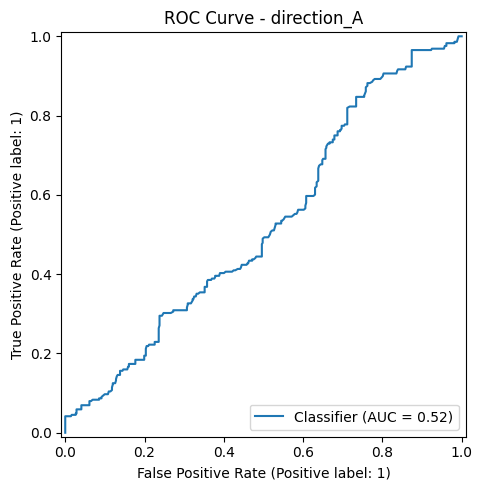

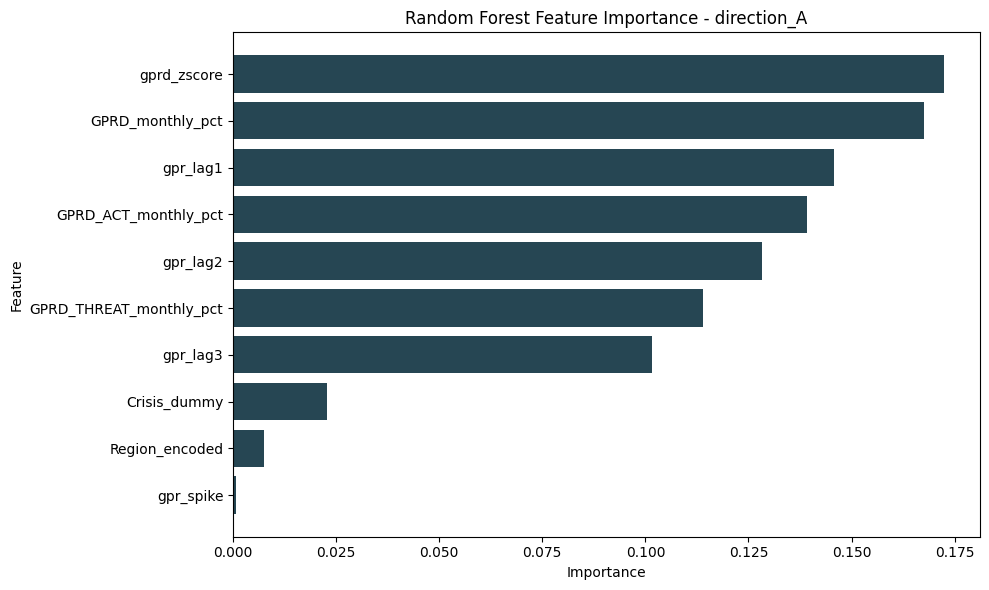

Direction A model saved to: d:\Anwendungsprojekt\results\models\random_forest_direction_A.pkl


,Direction,Target,Accuracy,Precision,Recall,F1,ROC_AUC,Baseline_Accuracy
0,direction_A,target_stock_down,0.498718,0.351585,0.423611,0.384252,0.524302,0.630769


In [4]:
result_A = fit_and_evaluate_direction("direction_A", FEATURES_A, TARGET_A)
metrics_A = result_A["metrics"]
print(f"Direction A model saved to: {result_A['model_path']}")
display(pd.DataFrame([metrics_A]))

# 5. Modeling - Random Forest Richtung B

Richtung B modelliert den Zusammenhang Aktien -> GPR mit `target_gpr_up_lead1` als Zielvariable.


direction_B - Classification report
              precision    recall  f1-score   support

           0       0.49      0.68      0.57       384
           1       0.50      0.31      0.38       396

    accuracy                           0.49       780
   macro avg       0.49      0.49      0.47       780
weighted avg       0.49      0.49      0.47       780

direction_B - Confusion matrix
[[260 124]
 [273 123]]


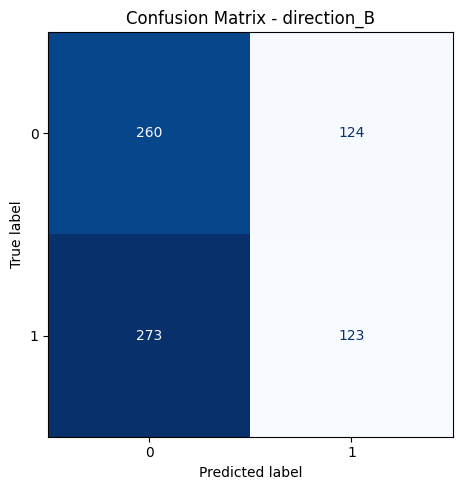

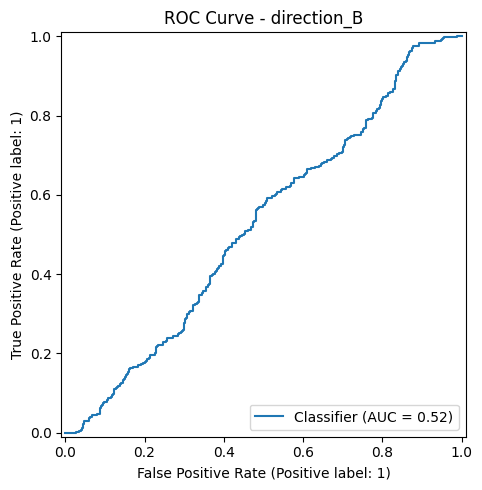

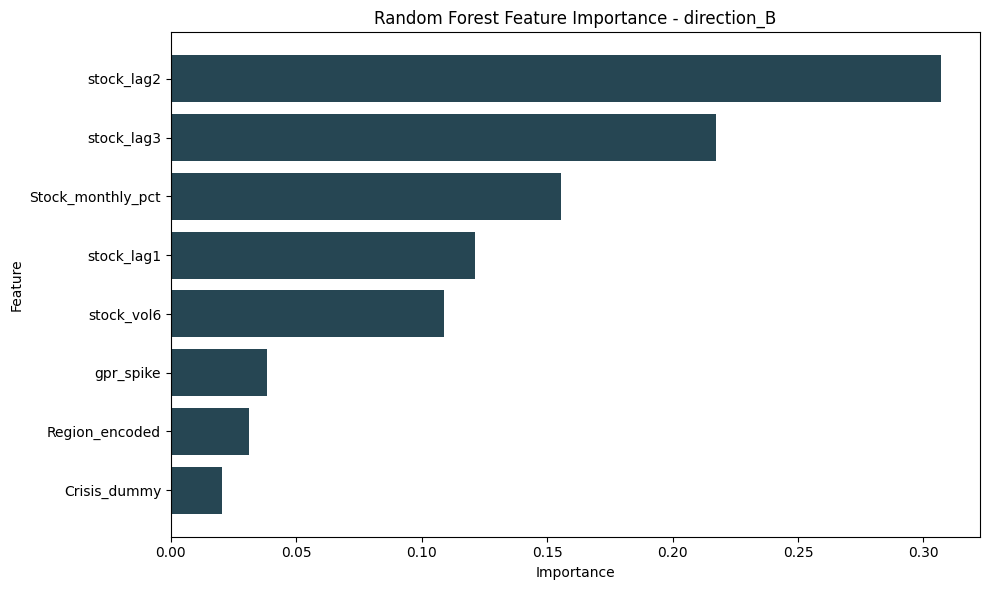

Direction B model saved to: d:\Anwendungsprojekt\results\models\random_forest_direction_B.pkl


,Direction,Target,Accuracy,Precision,Recall,F1,ROC_AUC,Baseline_Accuracy
0,direction_B,target_gpr_up_lead1,0.491026,0.497976,0.310606,0.382582,0.522471,0.507692


In [5]:
result_B = fit_and_evaluate_direction("direction_B", FEATURES_B, TARGET_B)
metrics_B = result_B["metrics"]
print(f"Direction B model saved to: {result_B['model_path']}")
display(pd.DataFrame([metrics_B]))

# 7. Evaluation

Die beiden Richtungen werden jetzt in einer gemeinsamen Tabelle verglichen und die Resultate werden als CSV exportiert.

In [6]:
comparison_table = pd.DataFrame([
    {
        "Direction": result_A["metrics"]["Direction"],
        "Target": result_A["metrics"]["Target"],
        "Accuracy": result_A["metrics"]["Accuracy"],
        "Precision": result_A["metrics"]["Precision"],
        "Recall": result_A["metrics"]["Recall"],
        "F1": result_A["metrics"]["F1"],
        "ROC_AUC": result_A["metrics"]["ROC_AUC"],
    },
    {
        "Direction": result_B["metrics"]["Direction"],
        "Target": result_B["metrics"]["Target"],
        "Accuracy": result_B["metrics"]["Accuracy"],
        "Precision": result_B["metrics"]["Precision"],
        "Recall": result_B["metrics"]["Recall"],
        "F1": result_B["metrics"]["F1"],
        "ROC_AUC": result_B["metrics"].get("ROC_AUC"),
    },
])

metrics_path = TABLES_DIR / "rf_metrics_2001_2021.csv"
comparison_table.to_csv(metrics_path, index=False)

print(f"Metrics table saved to: {metrics_path}")
display(comparison_table)

print("\nBaseline comparison:")
print(f"Direction A majority baseline: {result_A['metrics']['Baseline_Accuracy']:.4f}")
print(f"Direction B majority baseline: {result_B['metrics']['Baseline_Accuracy']:.4f}")

print("\nTop 5 features - Direction A")
display(result_A["importance"].head(5))
print("\nTop 5 features - Direction B")
display(result_B["importance"].head(5))

Metrics table saved to: d:\Anwendungsprojekt\results\tables\rf_metrics_2001_2021.csv


,Direction,Target,Accuracy,Precision,Recall,F1,ROC_AUC
0,direction_A,target_stock_down,0.498718,0.351585,0.423611,0.384252,0.524302
1,direction_B,target_gpr_up_lead1,0.491026,0.497976,0.310606,0.382582,0.522471



Baseline comparison:
Direction A majority baseline: 0.6308
Direction B majority baseline: 0.5077

Top 5 features - Direction A


,Feature,Importance
0,gprd_zscore,0.172523
1,GPRD_monthly_pct,0.167562
2,gpr_lag1,0.145766
3,GPRD_ACT_monthly_pct,0.139199
4,gpr_lag2,0.128171



Top 5 features - Direction B


,Feature,Importance
0,stock_lag2,0.307203
1,stock_lag3,0.217293
2,Stock_monthly_pct,0.155634
3,stock_lag1,0.121408
4,stock_vol6,0.108717


# 8. Feature Importance

Die Feature-Importances werden für beide Richtungen als CSV und Balkendiagramm gespeichert.

# 9. Plots

Confusion Matrices und ROC Curves werden für beide Richtungen unter `results/plots/` gespeichert.

# 10. Modell speichern

Die trainierten Random-Forest-Modelle werden unter `results/models/` abgelegt.

# 11. Interpretation

Die Richtung mit der höheren ROC-AUC ist knapp Richtung A (GPR -> Aktien) mit 0.5243 gegenüber 0.5225 in Richtung B (Aktien -> GPR). Der Unterschied ist klein und beide Modelle liegen nur leicht über Zufall, daher ist das Ergebnis inhaltlich schwach und nur vorsichtig zu interpretieren.

Gegen die Majority-Class-Baseline übertrifft Random Forest die Modelle hier nicht auf Accuracy-Basis: Richtung A erreicht 0.4987 bei einer Baseline von 0.6308, Richtung B erreicht 0.4910 bei einer Baseline von 0.5077. Das spricht gegen eine robuste Klassifikationsleistung im aktuellen Setup.

Die wichtigsten Features in Richtung A sind `gprd_zscore`, `GPRD_monthly_pct`, `gpr_lag1`, `GPRD_ACT_monthly_pct` und `gpr_lag2`. In Richtung B dominieren `stock_lag2`, `stock_lag3`, `Stock_monthly_pct`, `stock_lag1` und `stock_vol6`.

In Summe stützt das Ergebnis die Richtung GPR -> Aktien minimal stärker als Aktien -> GPR, aber nicht so deutlich, dass man daraus eine belastbare Schlussfolgerung ableiten sollte. Es handelt sich um Vorhersagezusammenhänge, nicht um Kausalität.

Wichtige Limitationen sind die monatliche Aggregation, die relativ kleine Zeitreihe, die Ausreißer in Krisenmonaten und die Tatsache, dass Random Forest Feature-Wichtigkeit zeigt, aber keine Kausalität.